# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

## 1. Préparation de l'environnement

Exécutez la cellule suivante pour importer les bibliothèques nécessaires.

## 2. Algorithme d'Euclide étendu

### Version récursive

Rappel : l'algorithme retourne $(d, u, v)$ tel que $d = a u + b v = \mathrm{pgcd}(a,b)$.

In [43]:
import timeit
import matplotlib.pyplot as plt
import math

%matplotlib inline

In [44]:
def euclide_etendu_rec(a, b):
    """
    Algorithme d'Euclide étendu (version récursive).
    Retourne (pgcd, u, v) avec a*u + b*v = pgcd.
    """
    if b == 0:
        return (a, 1, 0)
    else:
        d, u1, v1 = euclide_etendu_rec(b, a % b)
        u = v1
        v = u1 - (a // b) * v1
        return (d, u, v)

In [45]:
# Test rapide
a, b = 240, 46
d, u, v = euclide_etendu_rec(a, b)
print(f"pgcd({a}, {b}) = {d}")
print(f"{a}*{u} + {b}*{v} = {a*u + b*v}")

pgcd(240, 46) = 2
240*-9 + 46*47 = 2


### Version itérative (à compléter)

**Exercice** : Implémentez ci-dessous une version itérative de l'algorithme d'Euclide étendu. Vous pouvez utiliser une boucle `while` et mettre à jour les coefficients.

In [46]:
def euclide_etendu_iter(a, b):
    """
    Version itérative de l'algorithme d'Euclide étendu.
    """
    # Votre code ici
    u,v = 1,0
    u_1, v_1 = 0,1  #Coeff de a et b

    while b!=0:
        q = a // b
        r = a % b

        # r = a - bq et on a deux nouveaux u et v
        u_temp = u - q * u_1 
        v_temp = v - q * v_1

        # Mettre à jour les valeurs
        a,b = b,r
        u,v = u_1,v_1
        u_1,v_1 = u_temp,v_temp
    return(a,u,v)
    pass

In [47]:
# Test de votre version itérative
a, b = 240, 46
d, u, v = euclide_etendu_iter(a, b)
print(f"D'après la version itérative de l'Algorithme d'Euclide, on a :\nPgcd({a}, {b}) = {d}")
print(f"{a}({u}) + {b}({v}) = {a*u + b*v}")

D'après la version itérative de l'Algorithme d'Euclide, on a :
Pgcd(240, 46) = 2
240(-9) + 46(47) = 2


## 3. Crible d'Ératosthène

### Version de base

In [48]:
def eratosthene(n):
    """
    Retourne la liste des nombres premiers <= n.
    """
    ctr=0
    if n < 2:
        return []
    est_premier = [True] * (n+1)
    est_premier[0] = est_premier[1] = False
    for p in range(2, int(n**0.5) + 1):
        if est_premier[p]:
            for multiple in range(p*p, n+1, p):
                est_premier[multiple] = False
                ctr+=1
    return [[i for i, prime in enumerate(est_premier) if prime], ctr]
def cont_erat(n):
    return [eratosthene(10**k)[1] for k in range(1,n+1)]

In [49]:
# Test
print(eratosthene(50))

[[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47], 45]


### Version optimisée (nombres impairs uniquement)

**Exercice** : Modifiez le crible pour ne traiter que les nombres impairs (sauf 2).

In [50]:
def eratosthene_opt(n):
    """
    Crible optimisé pour ne parcourir que les impairs.
    """
    # Votre code ici
    ctr=0
    if n < 2:
        return [],0
    
    if n == 2 :
        return [2],0
    premiers = [2]
    est_premier = [True] * ((n // 2) + 1)
    est_premier[0] = False
    
    for i in range(1, int(n**0.5)//2 + 1):
        if est_premier[i]:
            p = 2*i + 1
            for multiple in range((p*p)//2, (n//2)+1, p):
                if est_premier[multiple]:
                    est_premier[multiple] = False
                    ctr+=1
                
    return [2*i + 1 for i, prime in enumerate(est_premier) if prime] , ctr
    pass

In [51]:
print(eratosthene_opt(10))

([3, 5, 7, 11], 1)


## 4. Analyse de complexité empirique

Nous allons mesurer le temps d'exécution du crible pour différentes valeurs de $n$.

In [52]:
def mesurer_temps(fonction, n, repetitions=5):
    """
    Mesure le temps moyen d'exécution de fonction(n) sur 'repetitions' exécutions.
    """
    timer = timeit.Timer(lambda: fonction(n))
    temps = timer.timeit(number=repetitions)
    return temps / repetitions

In [53]:
valeurs_n = [10**i for i in range(3, 8)]  # 10^3 à 10^7
temps_base = []
temps_opt = []

for n in valeurs_n:
    t_base = mesurer_temps(eratosthene, n, repetitions=3)
    # t_opt = mesurer_temps(eratosthene_opt, n, repetitions=3)  # décommentez quand votre fonction est prête
    temps_base.append(t_base)
    # temps_opt.append(t_opt)
    print(f"n = {n:7d} : temps base = {t_base:.4f} s")

n =    1000 : temps base = 0.0012 s
n =   10000 : temps base = 0.0073 s
n =  100000 : temps base = 0.0467 s
n = 1000000 : temps base = 0.2659 s
n = 10000000 : temps base = 3.3224 s


### Visualisation

On souhaite vérifier que le temps est proportionnel à $n \log \log n$.

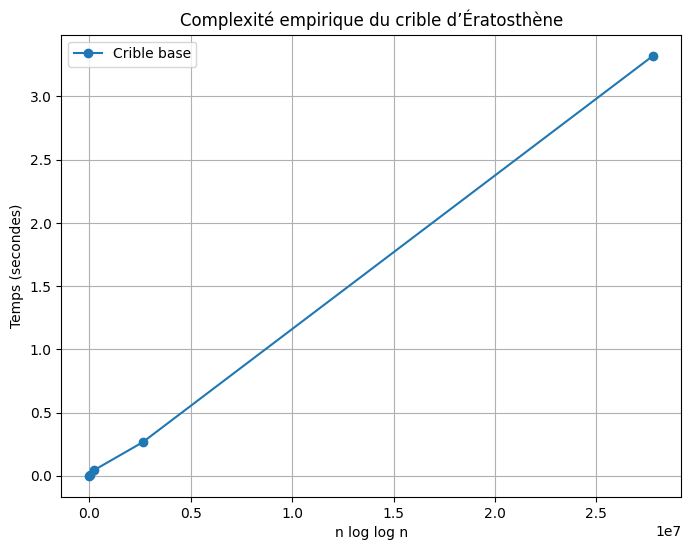

In [54]:
n_loglog = [n * math.log(math.log(n)) if n>2 else 0 for n in valeurs_n]

plt.figure(figsize=(8,6))
plt.plot(n_loglog, temps_base, 'o-', label='Crible base')
# plt.plot(n_loglog, temps_opt, 's-', label='Crible optimisé')  # à décommenter
plt.xlabel('n log log n')
plt.ylabel('Temps (secondes)')
plt.title('Complexité empirique du crible d’Ératosthène')
plt.legend()
plt.grid(True)
plt.show()

**Question** : Le graphique est-il approximativement une droite ? Que peut-on en conclure ?

## 5. Conclusion et rendu

- Assurez-vous que votre notebook contient **toutes** les fonctions demandées (versions récursive et itérative d'Euclide étendu, crible optimisé).
- Ajoutez des commentaires expliquant vos choix d'implémentation.
- Exportez ce notebook au format `.ipynb` et commitez-le dans votre dépôt GitHub.

**Rappel** : Vous pouvez utiliser l'IA comme assistant, mais vous devez comprendre chaque ligne de code et être capable de l'expliquer.